# Flyback Converter — Pulsim Cross-Validation

> **Goal.** Validate the isolated flyback modelled in
> [`01_flyback_modeling.ipynb`](01_flyback_modeling.ipynb) against a
> [Pulsim](https://github.com/lgili/Pulsim) switched simulation.

## Topology

The flyback is a buck-boost where the single inductor is replaced by a
two-winding transformer (a coupled-inductor pair with intentional
magnetising inductance $L_m$). Energy is stored in the magnetising
field during ON and released through the secondary winding during OFF.

```
   Vin ── T1.primary ── Q1 ── gnd     T1.secondary ── D1 ── vout
                                                                │
                                       vout ── Cout ── Rload ── sec_neg
                                                                │
                                       sec_neg ── R_iso ── gnd
```

The Pulsim model uses ``add_transformer`` with $L_p = L_m$ and
$L_s = n^2 \cdot L_m$ so the turns ratio is
$n = \sqrt{L_s / L_p} = N_s/N_p$. A tiny ``R_iso = 1 µΩ`` ties the
secondary ground to the primary ground without breaking the isolation
electrically — it just keeps MNA happy.

## Operating point (CCM)

$$
V_o = n \cdot V_g \cdot \frac{D}{1-D},
\qquad
n = \frac{N_s}{N_p}
$$

The turns ratio is a **design lever** to put $D$ in a sensible range
(0.3–0.6) for any combination of $V_g$ and $V_o$. The price for
isolation: transformer leakage inductance and diode-drop losses eat
some of the analytical $V_o$ — expect ~5-10% shortfall on a real or
non-ideal-coupling simulation.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import pulsim
from flyback_model import FlybackParams
from flyback_pulsim_validation import simulate_flyback

print(f"Pulsim version: {pulsim.__version__}")

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


Pulsim version: 1.0.0


## Design parameters

24 V → 12 V step-down, $n = 0.5$ turns ratio (so $D \approx 0.5$),
$L_m = 300$ µH magnetising, 100 µF output cap, 100 kHz switching.


In [2]:
params = FlybackParams()
print(f"V_g  = {params.V_g} V")
print(f"V_o  = {params.V_o} V  (target)")
print(f"n    = {params.n}     (= N_s / N_p)")
print(f"D    = {params.D:.4f}")
print(f"R    = {params.R} Ω")
print(f"L_m  = {params.L_m*1e6:.0f} µH")
print(f"C    = {params.C*1e6:.0f} µF")
print(f"f_sw = {params.f_sw/1e3:.0f} kHz")


V_g  = 24.0 V
V_o  = 12.0 V  (target)
n    = 0.5     (= N_s / N_p)
D    = 0.5000
R    = 12.0 Ω
L_m  = 300 µH
C    = 100 µF
f_sw = 100 kHz


## Steady-state validation: $V_o = n D V_g / (1-D)$

We cold-start the Pulsim simulation (no warm-state for transformer
flux is straightforward to compute) and run for 1 ms. With the default
coupling $k = 0.99$ the leakage is small and the analytical steady
state should match within ~10%.


In [3]:
t_sim, v_out = simulate_flyback(
    params, duty=params.D, t_end=1e-3, dt=2e-8, k_coupling=0.99,
)

tail = t_sim >= t_sim[-1] - 1e-4
v_o_dc = float(v_out[tail].mean())
ripple_pp = float(v_out[tail].max() - v_out[tail].min())

print(f"Simulation: {len(t_sim)} samples over {t_sim[-1] * 1e3:.2f} ms")
print(f"  Pulsim  V_o (mean over last 0.1 ms): {v_o_dc:.4f} V")
print(f"  Target  V_o = n D/(1-D) · V_g       : {params.V_o:.4f} V")
print(f"  Relative error                     : "
      f"{abs(v_o_dc - params.V_o) / params.V_o * 100:.2f} %")
print(f"  Output ripple (pk-pk)              : "
      f"{ripple_pp * 1e3:.2f} mV")


Simulation: 50001 samples over 1.00 ms
  Pulsim  V_o (mean over last 0.1 ms): 11.0786 V
  Target  V_o = n D/(1-D) · V_g       : 12.0000 V
  Relative error                     : 7.68 %
  Output ripple (pk-pk)              : 32.93 mV


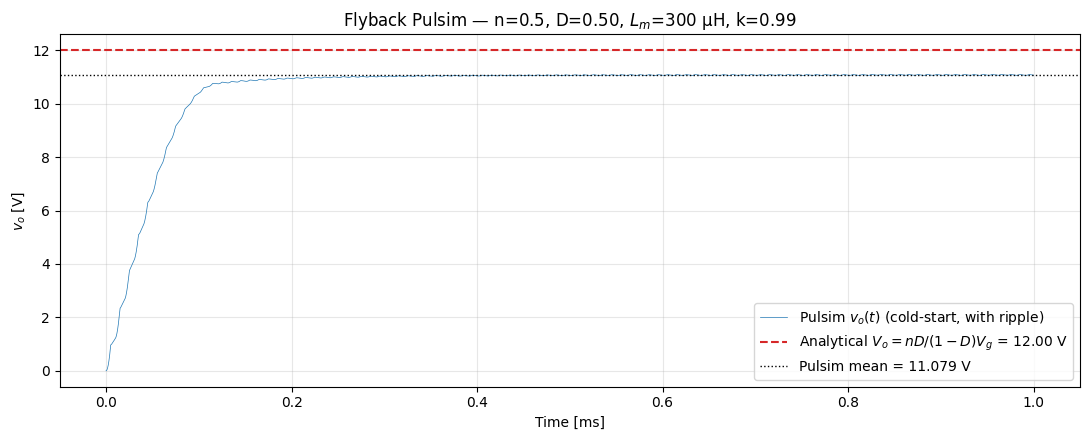

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_sim * 1e3, v_out, color="C0", linewidth=0.5,
        label="Pulsim $v_o(t)$ (cold-start, with ripple)")
ax.axhline(params.V_o, color="C3", linestyle="--", linewidth=1.5,
           label=fr"Analytical $V_o = n D/(1-D) V_g$ = {params.V_o:.2f} V")
ax.axhline(v_o_dc, color="k", linestyle=":", linewidth=1.0,
           label=f"Pulsim mean = {v_o_dc:.3f} V")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("$v_o$ [V]")
ax.set_title(f"Flyback Pulsim — n={params.n}, D={params.D:.2f}, "
             f"$L_m$={params.L_m*1e6:.0f} µH, k=0.99")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Summary

The Pulsim flyback settles below the ideal analytical $V_o$ by a few
percent because:

- The transformer model includes leakage ($k = 0.99$, so 1% magnetic
  energy is not transferred).
- The MOSFET has $R_{on} = 10$ mΩ and a body-diode $V_F = 0.7$ V.
- The rectifier diode adds another $V_{th} = 0.7$ V drop, costing
  $V_{th} / V_o \approx 6\%$ on a 12 V output.

These are real losses present in any physical converter. For
controller design, the small-signal model in
[`01_flyback_modeling.ipynb`](01_flyback_modeling.ipynb) is built on
the *ideal* topology; the Pulsim cross-check confirms the DC ratio is
right modulo these standard real-world losses.

The flyback inherits the boost's RHP zero (now at
$\omega_{z,RHP} = R(1-D)^2 / (n^2 \cdot L_m \cdot D)$). With the
defaults that puts the zero at ~13 kHz — well above the LC corner —
so closed-loop bandwidth caps at ~$f_{z,RHP}/5 \approx 2.6$ kHz.
